In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (classification_report,confusion_matrix, roc_auc_score,cohen_kappa_score, f1_score )
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
features_df = pd.read_csv('../data/processed/subject_01/night_1/features.csv')

In [5]:
X = features_df.drop('label',axis=1)
y = features_df['label']
print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts().sort_index}()")

X shape: (935, 17)
y distribution: <bound method Series.sort_index of label
2    347
3    273
4    248
0     36
1     31
Name: count, dtype: int64>()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"\nTrain label distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest label distribution:\n{y_test.value_counts().sort_index()}")


Train size: 748
Test size:  187

Train label distribution:
label
0     29
1     25
2    278
3    218
4    198
Name: count, dtype: int64

Test label distribution:
label
0     7
1     6
2    69
3    55
4    50
Name: count, dtype: int64


In [ ]:
model = RandomForestClassifier(
    n_estimators = 200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [14]:
label_map = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

print("="*55)
print("                CLASSIFICATION REPORT")
print("="*55)
print(classification_report(
    y_test, y_pred,
    target_names=target_names,
    digits=3
))

                CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Wake      0.625     0.714     0.667         7
          N1      0.667     0.333     0.444         6
          N2      0.926     0.913     0.920        69
          N3      0.964     0.964     0.964        55
         REM      0.906     0.960     0.932        50

    accuracy                          0.914       187
   macro avg      0.817     0.777     0.785       187
weighted avg      0.912     0.914     0.911       187



In [ ]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

if kappa < 0.20:
    interpretation = "Slight agreement"
elif kappa < 0.40:
    interpretation = "Fair agreement"
elif kappa < 0.60:
    interpretation = "Moderate agreement"
elif kappa < 0.80:
    interpretation = "Substantial agreement"
else:
    interpretation = "Almost perfect agreement"

print(f"Interpretation: {interpretation}")

Cohen's Kappa: 0.8780
Interpretation: Almost perfect agreement


In [16]:
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# AUC-ROC (one-vs-rest for multiclass)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
auc_roc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr',
    average='macro'
)
print(f"Macro AUC-ROC: {auc_roc:.4f}")

Macro F1:    0.7853
Weighted F1: 0.9112
Macro AUC-ROC: 0.9275


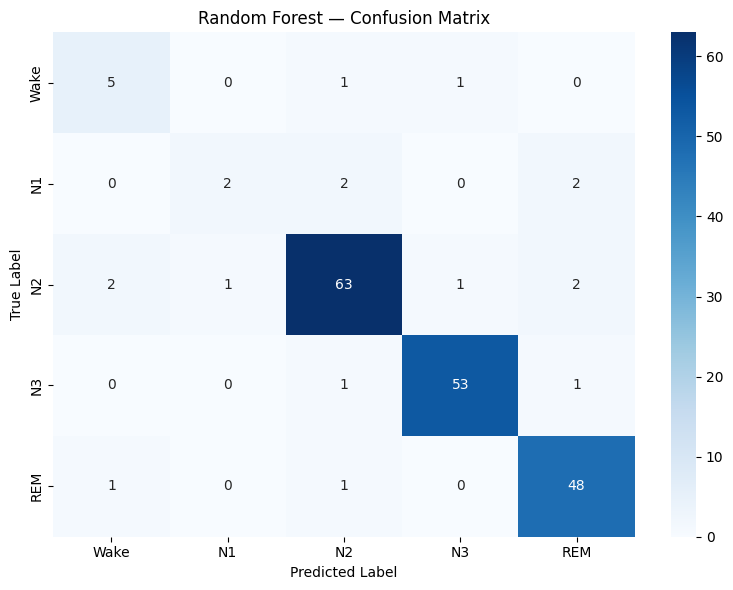

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../data/processed/subject_01/night_1/rf_confusion_matrix.png', dpi=150)
plt.show()

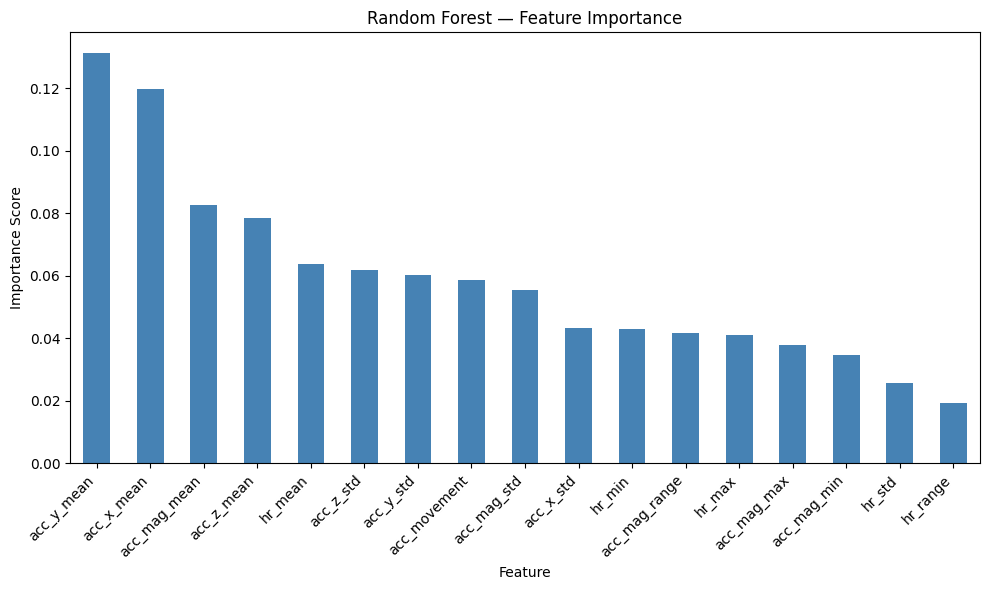


Top 5 most important features:
acc_y_mean      0.131359
acc_x_mean      0.119808
acc_mag_mean    0.082567
acc_z_mean      0.078518
hr_mean         0.063872
dtype: float64


In [21]:
importances = model.feature_importances_
feature_names = X.columns.tolist()

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/subject_01/night_1/rf_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.head())

In [22]:
results = {
    'model': 'Random Forest',
    'n_estimators': 200,
    'class_weight': 'balanced',
    'train_size': len(X_train),
    'test_size': len(X_test),
    'macro_f1': round(macro_f1, 4),
    'weighted_f1': round(weighted_f1, 4),
    'auc_roc': round(auc_roc, 4),
    'cohen_kappa': round(kappa, 4),
    'kappa_interpretation': interpretation
}

results_df = pd.DataFrame([results])
results_df.to_csv('../reports/rf_results.csv', index=False)
print("Results saved")
print(results_df.T)

Results saved
                                             0
model                            Random Forest
n_estimators                               200
class_weight                          balanced
train_size                                 748
test_size                                  187
macro_f1                                0.7853
weighted_f1                             0.9112
auc_roc                                 0.9275
cohen_kappa                              0.878
kappa_interpretation  Almost perfect agreement
